In [2]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def is_homogeneous(region, threshold):
    """Check if the region is homogeneous based on intensity threshold."""
    min_val, max_val = np.min(region), np.max(region)
    return (max_val - min_val) <= threshold


def split_and_merge(image, threshold):
    """Segment the image using recursive splitting."""
    
    def recursive_split(region):
        rows, cols = region.shape
        
        if rows <= 1 or cols <= 1:
            return np.zeros_like(region, dtype=np.uint8)
        
        if is_homogeneous(region, threshold):
            return np.ones_like(region, dtype=np.uint8)
        
        mid_row, mid_col = rows // 2, cols // 2
        
        top_left = region[:mid_row, :mid_col]
        top_right = region[:mid_row, mid_col:]
        bottom_left = region[mid_row:, :mid_col]
        bottom_right = region[mid_row:, mid_col:]
        
        segmented = np.zeros_like(region, dtype=np.uint8)
        
        segmented[:mid_row, :mid_col] = recursive_split(top_left)
        segmented[:mid_row, mid_col:] = recursive_split(top_right)
        segmented[mid_row:, :mid_col] = recursive_split(bottom_left)
        segmented[mid_row:, mid_col:] = recursive_split(bottom_right)
        
        return segmented

    return recursive_split(image)

In [8]:
# OPTION 1: Load from file
file_path = r"D:/ippr/experiment_1/image.jpg"
image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Image not loaded properly")

In [9]:
threshold = 20  # tune this
segmented = split_and_merge(image, threshold)

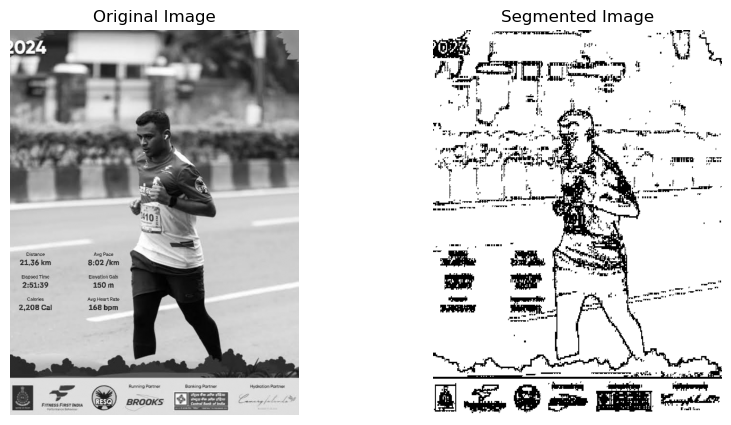

In [10]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Segmented Image")
plt.imshow(segmented * 255, cmap='gray')
plt.axis('off')

plt.show()